In [1]:
import sys
import os
import gc
import pandas as pd
import joblib
import matplotlib.pyplot as plt

#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/nikko/miniconda3/envs/comp_phys/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [2]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------

star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

star.info()


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

In [3]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)


Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)

Class Distribution:
class
GALAXY    59.445
STAR      21.594
QSO       18.961
Name: proportion, dtype: float64


In [4]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")

DataLoaders created.


In [5]:
# Train and evaluate traditional ML models
models = sc.train_traditional(X_train, y_train, X_val, y_val)


Linear SVC trained.
  [Training] Acc=73.09%  P=0.73  R=0.73  F1=0.73
  [Validation] Acc=71.57%  P=0.67  R=0.72  F1=0.69
Decision Tree trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=84.89%  P=0.81  R=0.83  F1=0.82
Random Forest trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=90.40%  P=0.88  R=0.88  F1=0.88
CatBoost trained.
  [Training] Acc=94.72%  P=0.95  R=0.95  F1=0.95
  [Validation] Acc=90.24%  P=0.87  R=0.88  F1=0.88
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 13 dense feature groups (1.48 MB) transferred to GPU in 0.003336 secs. 

In [6]:
import torch
torch.cuda.empty_cache()

if os.path.exists('trained_models/stacking_clf_index_NOz.pkl'):
    stacking_clf = joblib.load('trained_models/stacking_clf_index_NOz.pkl')
    print("Stacking Classifier caricato da disco")
else:
    stacking_clf = sc.train_stacking(X_train, y_train, X_val, y_val, n_jobs=2)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(stacking_clf, 'trained_models/stacking_clf_index_NOz.pkl')
    print("Stacking Classifier trained and saved")

Linear SVC trained.
Decision Tree trained.
Random Forest trained.
CatBoost trained.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004801 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LightGBM trained.
starting training...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005558 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start train

In [7]:
if os.path.exists('trained_models/voting_clf_index_NOz.pkl'):
    voting_clf = joblib.load('trained_models/voting_clf_index_NOz.pkl')
    print("Voting Classifier caricato da disco")
else:
    voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(voting_clf, 'trained_models/voting_clf_index_NOz.pkl')
    print("Voting Classifier trained and saved")

# for m in (train_m, val_m):
#         print(
#             f"  [{m['dataset']}] Acc={m['accuracy']:.2f}%  "
#             f"P={m['precision']:.2f}  R={m['recall']:.2f}  F1={m['f1']:.2f}"
#         )

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 13 dense feature groups (1.48 MB) transferred to GPU in 0.003425 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Voting Classifier trained.
  [Training] Acc=96.50%  P=0.97  R=0.96  F1=0.96
  [Validation] Acc=90.57%  P=0.88  R=0.88  F1=0.88
Voting Classifier trained and saved


In [8]:
import torch
from stellar_classification.models.network import SimpleNN

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

if os.path.exists('trained_models/nn_model_index_NOz.pth'):
    nn_model = SimpleNN(input_size, num_classes)
    nn_model.load_state_dict(torch.load('trained_models/nn_model_index_NOz.pth'))
    nn_model.eval()
    print("NN caricata da disco")
else:
    nn_model = sc.train_neural( 
        train_loader=train_loader,
        val_loader=val_loader,
        input_size=input_size,
        num_classes=num_classes,
        num_epochs=10,
        lr=0.001
    )
    torch.save(nn_model.state_dict(), 'trained_models/nn_model_index_NOz.pth')
    print("NN trained nad saved")

Epoch  1/10  loss=0.4935  val_acc=85.69%
Epoch  2/10  loss=0.4203  val_acc=85.62%
Epoch  3/10  loss=0.3997  val_acc=85.99%
Epoch  4/10  loss=0.3861  val_acc=86.00%
Epoch  5/10  loss=0.3756  val_acc=86.91%
Epoch  6/10  loss=0.3667  val_acc=87.86%
Epoch  7/10  loss=0.3597  val_acc=87.47%
Epoch  8/10  loss=0.3537  val_acc=87.08%
Epoch  9/10  loss=0.3497  val_acc=87.17%
Epoch 10/10  loss=0.3451  val_acc=87.14%
NN trained nad saved


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

y_test_pred_stacking = stacking_clf.predict(X_test)
stacking_metrics = sc.evaluate_test_set(y_test, y_test_pred_stacking, "Stacking Classifier")
sc.print_metrics(stacking_metrics)
    
nn_metrics = sc.evaluate_neural(test_loader, nn_model, device, "Neural Network")
sc.print_metrics(nn_metrics)



Voting Classifier:
  Accuracy  : 90.82%
  Precision: 0.8817
  Recall   : 0.8844
  F1       : 0.8822
  Confusion Matrix:
[[10215   355   211]
 [  222  3116   210]
 [  290   388  3250]]

Stacking Classifier:
  Accuracy  : 90.11%
  Precision: 0.8712
  Recall   : 0.8729
  F1       : 0.8719
  Confusion Matrix:
[[10201   334   246]
 [  253  2981   314]
 [  300   359  3269]]

Neural Network:
  Accuracy  : 87.74%
  Precision: 0.8406
  Recall   : 0.8593
  F1       : 0.8477
  Confusion Matrix:
[[9797  552  432]
 [ 193 3135  220]
 [ 332  510 3086]]


Saved: /home/nikko/Immagini/res/conf_matrix/voting_matrix_index_NOz


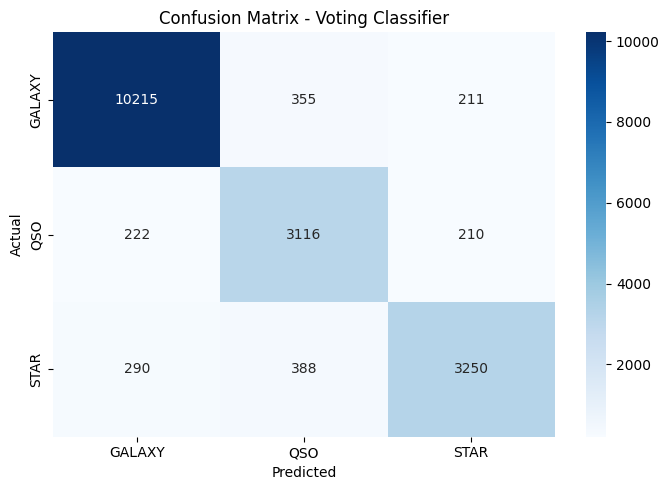

Saved: /home/nikko/Immagini/res/conf_matrix/staking_matrix_index_NOz


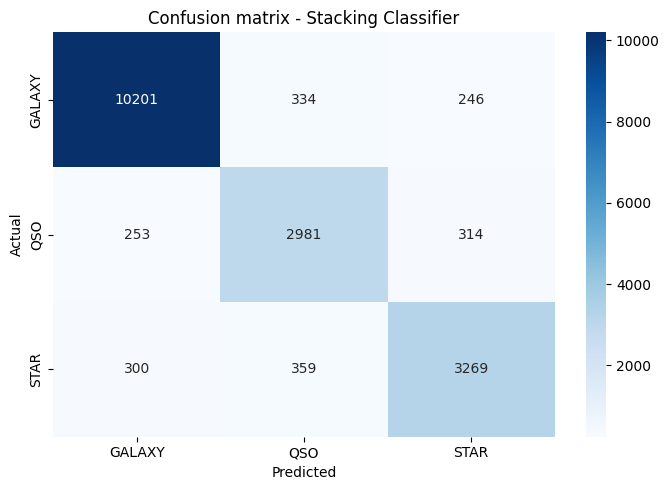

Saved: /home/nikko/Immagini/res/conf_matrix/NN_matrix_index_NOz


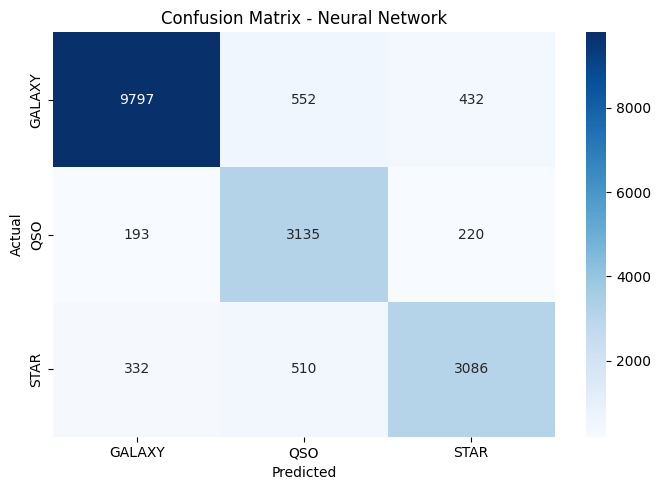

In [10]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier', save_path='/home/nikko/Immagini/res/conf_matrix/voting_matrix_index_NOz')
sc.plot_confusion_matrix(stacking_metrics['confusion_matrix'], class_names=class_names, title='Confusion matrix - Stacking Classifier', save_path='/home/nikko/Immagini/res/conf_matrix/staking_matrix_index_NOz')
sc.plot_confusion_matrix(nn_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Neural Network', save_path='/home/nikko/Immagini/res/conf_matrix/NN_matrix_index_NOz')


1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2257
[array([0.0043 , 0.00305, 0.00305, 0.007  , 0.00205, 0.0008 , 0.00535,
       0.031  , 0.01325, 0.092  , 0.1046 , 0.1617 , 0.0531 ]), array([0.00515, 0.00605, 0.0077 , 0.0112 , 0.00425, 0.0051 , 0.0098 ,
       0.04045, 0.0174 , 0.0958 , 0.09425, 0.1733 , 0.0641 ]), array([0.0038 , 0.00585, 0.0047 , 0.00935, 0.0041 , 0.00655, 0.0077 ,
       0.0402 , 0.01565, 0.09495, 0.1001 , 0.16185, 0.05325]), array([0.00715, 0.0068 , 0.00645, 0.01   , 0.00405, 0.005  , 0.0063 ,
       0.03535, 0.0203 , 0.0948 , 0.09715, 0.1732 , 0.05   ]), array([ 0.0026584 ,  0.00389898,  0.00398759,  0.01001329, -0.00026584,
       -0.00053168,  0.00248117,  0.03331856,  0.01382366,  0.09809482,
        0.09534781,  0.16074435,  0.05263624])]
Saved: /home/nikko/Immagini/res/permutation_importances/voting_perm_index_NOz.png


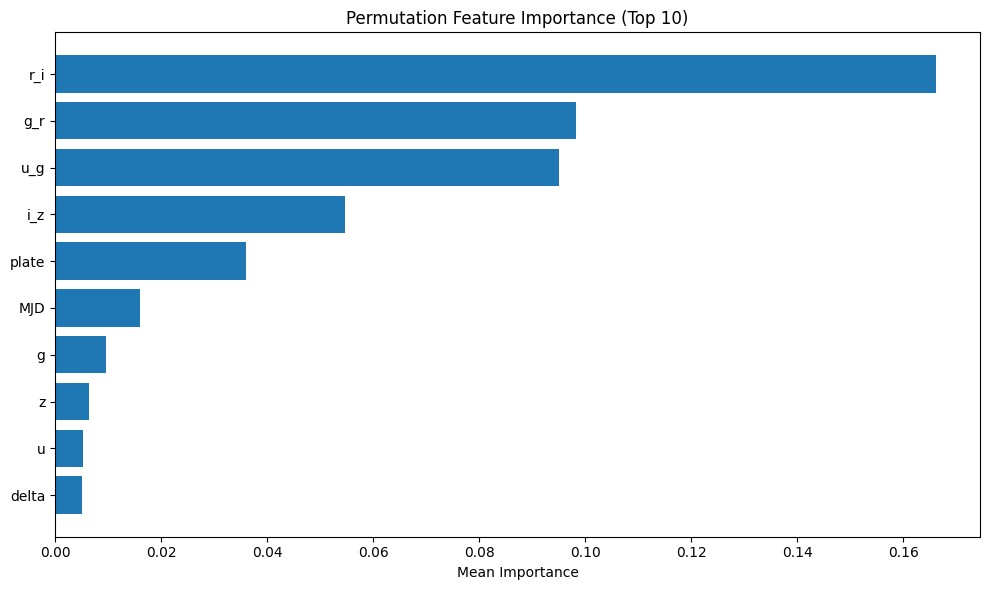

Feature Importance Scores:
r_i: 0.1662
g_r: 0.0983
u_g: 0.0951
i_z: 0.0546
plate: 0.0361
MJD: 0.0161
g: 0.0095
z: 0.0063
u: 0.0052
delta: 0.0051
alpha: 0.0046
i: 0.0034
r: 0.0028
1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2257
[array([0.0016 , 0.00265, 0.053  , 0.0227 , 0.0081 , 0.0125 , 0.01535,
       0.02805, 0.0251 , 0.1043 , 0.0779 , 0.23355, 0.077  ]), array([0.00065, 0.0034 , 0.05105, 0.0217 , 0.00715, 0.0117 , 0.01765,
       0.0295 , 0.0258 , 0.108  , 0.07115, 0.22855, 0.0818 ]), array([0.00135, 0.0038 , 0.0481 , 0.02005, 0.00755, 0.013  , 0.0208 ,
       0.0253 , 0.02465, 0.10075, 0.07175, 0.22025, 0.07585]), array([0.00245, 0.00175, 0.05165, 0.0202 , 0.00775, 0.0149 , 0.01925,
       0.0322 , 0.0276 , 0.10265, 0.07425, 0.2381 , 0.07945]), array([0.0020381 , 0.00549402, 0.05449712, 0.0201152 , 0.01001329,
       0.01160833, 0.01391227, 0.02738148, 0.02454586, 0.11103234,
       0.07221976, 0.22676119, 0.08356225])]
Saved: /h

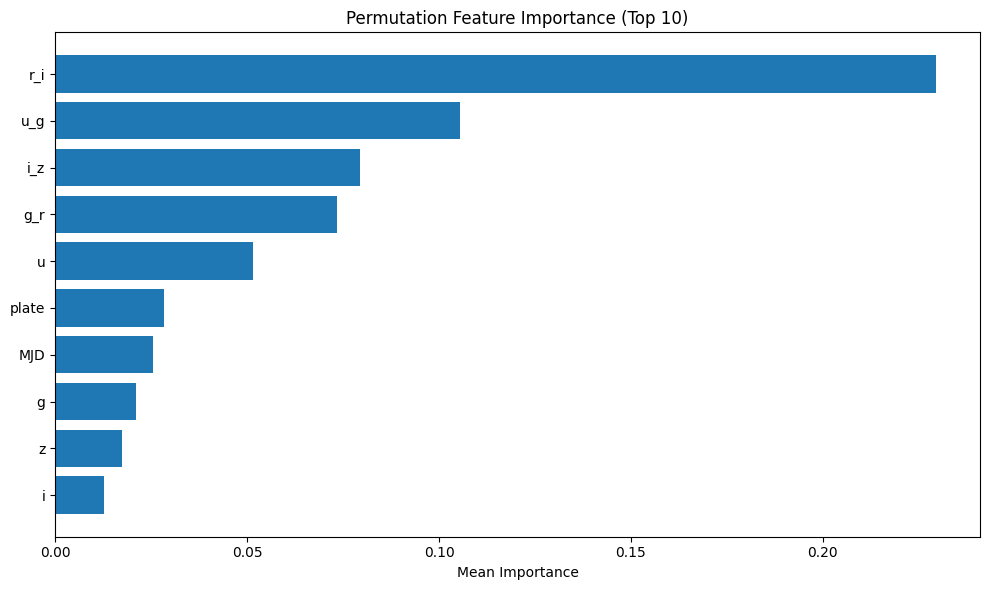

Feature Importance Scores:
r_i: 0.2294
u_g: 0.1053
i_z: 0.0795
g_r: 0.0735
u: 0.0517
plate: 0.0285
MJD: 0.0255
g: 0.0210
z: 0.0174
i: 0.0127
r: 0.0081
delta: 0.0034
alpha: 0.0016


In [11]:
imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10, save_path='/home/nikko/Immagini/res/permutation_importances/voting_perm_index_NOz.png')

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")

imp = sc.compute_permutation_importance(stacking_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10, save_path='/home/nikko/Immagini/res/permutation_importances/stacking_perm_index_NOz.png')

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}") 



In [12]:
# def classify(index):

#     res = stacking_clf.predict(star[index])
#     classes = {0:'Galasy', 1:'Quasar', 2:'Star'}
#     return classes[res[0]]



In [13]:
# classify(7)

In [14]:
# print(star.type())